# Sweep-Analyse — amtown03 + agz

Liest `output/sweep_results.csv` und erstellt:
1. Pareto PSNR vs Laufzeit (pro Dataset)
2. Laufzeiten-Übersicht
3. Status-Bilanz (ok / partial / dead)
4. Konsens-Histogramm: pro Frame-Index Anzahl der Selektor-Varianten, die ihn gemappt haben
5. Top-N-Tabelle
6. Missing-Data-Heatmap

**Status-Klassifizierung:**
- `ok`: CSV `status == OK` (rc=0, sauber durchgelaufen)
- `partial`: `status == FAIL` aber PSNR steht in der CSV → vom VRAM-Watchdog (rc=137) gekillt, Metriken bereits geschrieben
- `dead`: `status == FAIL` und PSNR leer → echter Crash

In [12]:
!pip install numpy pandas matplotlib

In [13]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

REPO = Path('/home/philipp/Dokumente/Github/VINGS-Mono-BA')
CSV  = REPO / 'output' / 'sweep_results.csv'
df = pd.read_csv(CSV)

def classify(row):
    if row['status'] == 'OK':
        return 'ok'
    return 'partial' if pd.notna(row['psnr']) else 'dead'
df['status3'] = df.apply(classify, axis=1)

# Doppel-Runs (re-tries nach Sweep-Unterbrechung): nimm den späteren Eintrag pro (dataset, variant)
df = df.sort_values('timestamp_start').drop_duplicates(['dataset','variant'], keep='last').reset_index(drop=True)

print(f'Runs: {len(df)}')
print(df.groupby(['dataset','status3']).size().unstack(fill_value=0))

Runs: 90
status3   dead  ok  partial
dataset                    
agz          0   4       41
amtown03     1   2       42


## 1) Pareto: PSNR vs Wall-Time

Wall-Time aus `wall_total_s` (Sekunden). PSNR aus der CSV — bei `partial` ist das die PSNR über das (kürzere) gemappte Subset. **Achtung:** ein Run mit nur 50 gemappten Frames vergleicht sich nicht 1:1 zu einem mit 500 — siehe Plot 5 für die Caveats.

/tmp/ipykernel_2143283/3916805140.py:11: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(r['wall_total_s']/60.0, r['psnr'],
/tmp/ipykernel_2143283/3916805140.py:11: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(r['wall_total_s']/60.0, r['psnr'],


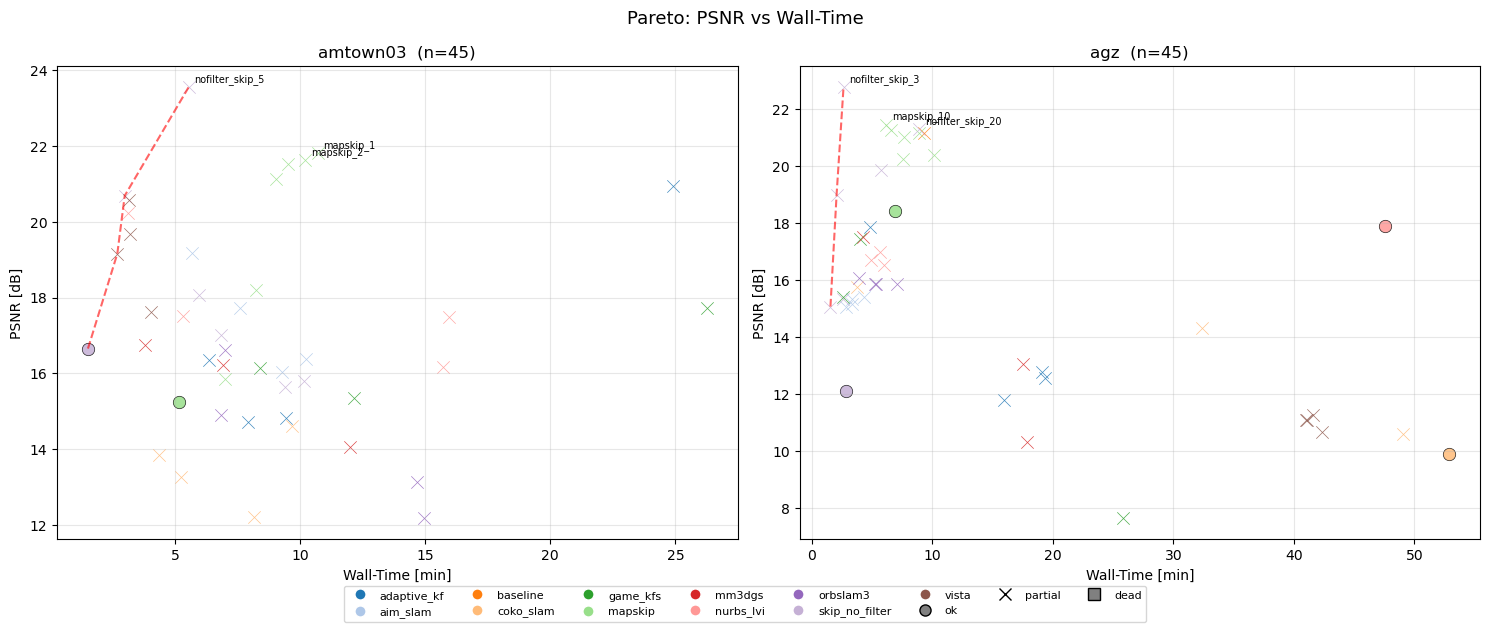

In [14]:
GROUPS = sorted(df['group'].unique())
GROUP_COLOR = dict(zip(GROUPS, plt.cm.tab20.colors[:len(GROUPS)]))
STATUS_MARKER = {'ok':'o', 'partial':'x', 'dead':'s'}

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False)
for ax, ds in zip(axes, ['amtown03','agz']):
    sub = df[df['dataset']==ds]
    for _, r in sub.iterrows():
        if pd.isna(r['psnr']) or pd.isna(r['wall_total_s']):
            continue
        ax.scatter(r['wall_total_s']/60.0, r['psnr'],
                   c=[GROUP_COLOR[r['group']]],
                   marker=STATUS_MARKER[r['status3']],
                   s=80, alpha=0.85, edgecolor='black', linewidth=0.5)
    # Pareto-Front (max PSNR pro Wall-Time-Bucket)
    valid = sub.dropna(subset=['psnr','wall_total_s']).sort_values('wall_total_s')
    pareto_x, pareto_y, best = [], [], -np.inf
    for _, r in valid.iterrows():
        if r['psnr'] > best:
            best = r['psnr']
            pareto_x.append(r['wall_total_s']/60.0); pareto_y.append(r['psnr'])
    ax.plot(pareto_x, pareto_y, '--', color='red', lw=1.5, alpha=0.6, label='Pareto-Front')
    ax.set_xlabel('Wall-Time [min]'); ax.set_ylabel('PSNR [dB]')
    ax.set_title(f'{ds}  (n={len(sub)})')
    ax.grid(alpha=0.3)
    # Top-3 beschriften
    for _, r in sub.nlargest(3, 'psnr').iterrows():
        ax.annotate(r['variant'], (r['wall_total_s']/60.0, r['psnr']),
                    fontsize=7, xytext=(4,4), textcoords='offset points')

# Gemeinsame Legende
legend_groups = [Line2D([0],[0], marker='o', color='w', markerfacecolor=GROUP_COLOR[g], markersize=8, label=g) for g in GROUPS]
legend_status = [Line2D([0],[0], marker=m, color='black', markerfacecolor='gray', markersize=8, label=s, linestyle='') for s,m in STATUS_MARKER.items()]
fig.legend(handles=legend_groups+legend_status, loc='lower center', ncol=8, fontsize=8, bbox_to_anchor=(0.5,-0.05))
fig.suptitle('Pareto: PSNR vs Wall-Time', fontsize=13)
fig.tight_layout(); plt.show()

## 2) Laufzeiten generell

Boxplot Wall-Time pro Selector-Gruppe.

/tmp/ipykernel_2143283/1642552459.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=order, vert=True, patch_artist=True, showmeans=True)
/tmp/ipykernel_2143283/1642552459.py:15: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(i+jitter, r['wall_min'], c='red' if r['status3']=='dead' else ('orange' if r['status3']=='partial' else 'green'),
/tmp/ipykernel_2143283/1642552459.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=order, vert=True, patch_artist=True, showmeans=True)
/tmp/ipykernel_2143283/1642552459.py:15: UserWarning:

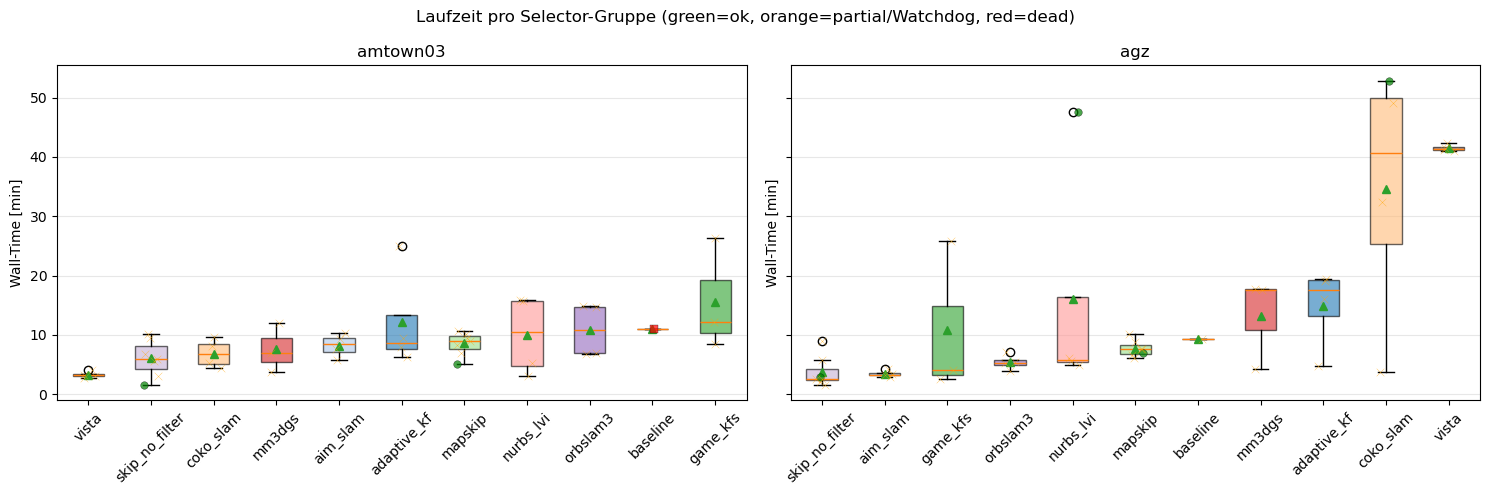

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, ds in zip(axes, ['amtown03','agz']):
    sub = df[df['dataset']==ds].copy()
    sub['wall_min'] = sub['wall_total_s'] / 60.0
    order = sub.groupby('group')['wall_min'].median().sort_values().index.tolist()
    data = [sub[sub['group']==g]['wall_min'].dropna().values for g in order]
    bp = ax.boxplot(data, labels=order, vert=True, patch_artist=True, showmeans=True)
    for patch, g in zip(bp['boxes'], order):
        patch.set_facecolor(GROUP_COLOR[g]); patch.set_alpha(0.6)
    # Punkte überlegen, Status farbig
    for i, g in enumerate(order, start=1):
        gsub = sub[sub['group']==g]
        for _, r in gsub.iterrows():
            jitter = (np.random.rand()-0.5)*0.25
            ax.scatter(i+jitter, r['wall_min'], c='red' if r['status3']=='dead' else ('orange' if r['status3']=='partial' else 'green'),
                       marker=STATUS_MARKER[r['status3']], s=30, alpha=0.7, edgecolor='black', linewidth=0.3, zorder=3)
    ax.set_title(f'{ds}'); ax.set_ylabel('Wall-Time [min]')
    ax.tick_params(axis='x', rotation=45); ax.grid(alpha=0.3, axis='y')
fig.suptitle('Laufzeit pro Selector-Gruppe (green=ok, orange=partial/Watchdog, red=dead)', fontsize=12)
fig.tight_layout(); plt.show()

## 3) Status-Bilanz pro Selector-Gruppe

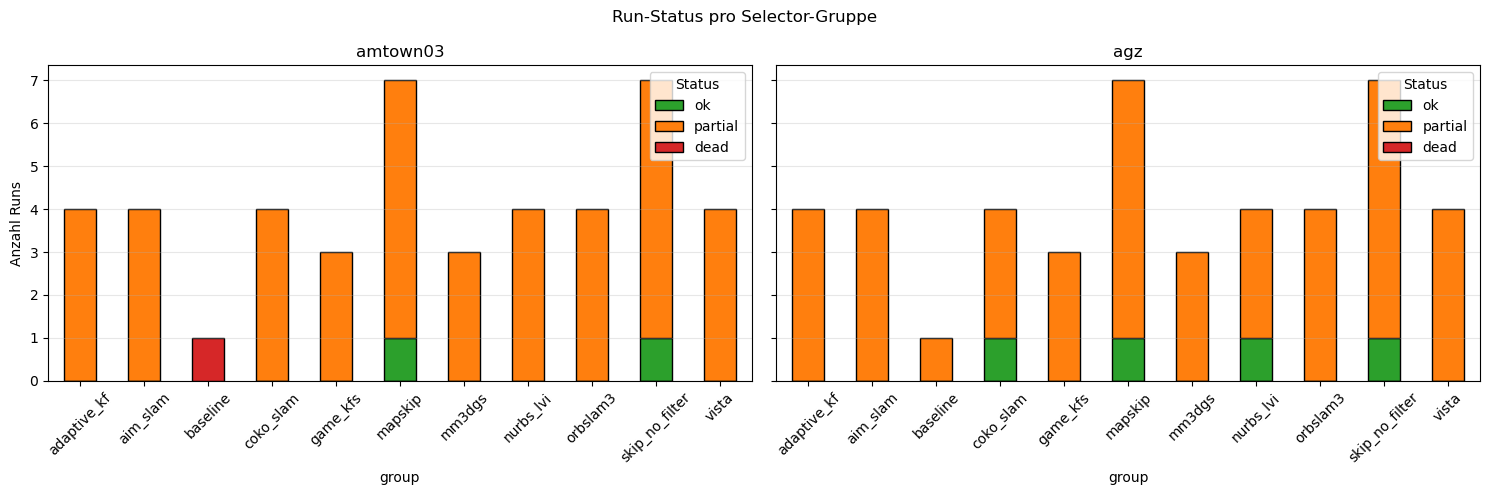

Total:
status3   dead  ok  partial
dataset                    
agz          0   4       41
amtown03     1   2       42


In [16]:
STATUS_COLOR = {'ok':'#2ca02c', 'partial':'#ff7f0e', 'dead':'#d62728'}
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, ds in zip(axes, ['amtown03','agz']):
    sub = df[df['dataset']==ds]
    pivot = sub.groupby(['group','status3']).size().unstack(fill_value=0)
    for s in ['ok','partial','dead']:
        if s not in pivot.columns: pivot[s] = 0
    pivot = pivot[['ok','partial','dead']]
    pivot.plot(kind='bar', stacked=True, ax=ax,
               color=[STATUS_COLOR[s] for s in pivot.columns], edgecolor='black')
    ax.set_title(f'{ds}'); ax.set_ylabel('Anzahl Runs')
    ax.tick_params(axis='x', rotation=45); ax.grid(alpha=0.3, axis='y')
    ax.legend(title='Status', loc='upper right')
fig.suptitle('Run-Status pro Selector-Gruppe', fontsize=12)
fig.tight_layout(); plt.show()

print('Total:')
print(df.groupby(['dataset','status3']).size().unstack(fill_value=0))

## 4) KF-Konsens-Histogramm

Pro Run-Log werden die `[idx] kf=Y`-Marker (mapped frames) extrahiert. Für jeden Frame-Index wird gezählt, wie viele Selektor-Varianten ihn gemappt haben. Frames mit hohem Score sind „universell wichtig" (alle Selektoren akzeptieren), Frames mit niedrigem Score sind selten/idiosynkratisch.

Parser liest die Run-Logs einmal — kann ~30 s dauern.

In [17]:
KF_PATTERN = re.compile(rb'\[ *(\d+)\] kf=Y')

def parse_mapped_frames(log_path: Path):
    """Liest die kf=Y Frame-Indizes aus einem Run-Log (handhabt \r-Overwrites)."""
    try:
        with open(log_path, 'rb') as f:
            data = f.read()
    except FileNotFoundError:
        return np.array([], dtype=np.int64)
    data = data.replace(b'\r', b'\n')
    return np.fromiter((int(m.group(1)) for m in KF_PATTERN.finditer(data)), dtype=np.int64)

# Pro (dataset, variant) Frame-Indizes sammeln
frames_by_variant = {}
for _, r in df.iterrows():
    if pd.isna(r['log_path']):
        continue
    log_path = Path(r['log_path'])
    arr = parse_mapped_frames(log_path)
    if len(arr) == 0:
        continue
    frames_by_variant[(r['dataset'], r['variant'])] = np.unique(arr)

print(f'Parsed {len(frames_by_variant)} runs')
print('Beispiel:', list(frames_by_variant.items())[0])

Parsed 90 runs
Beispiel: (('amtown03', 'vings_filter'), array([  65,   66,   67, ..., 3636, 3637, 3638], shape=(3574,)))


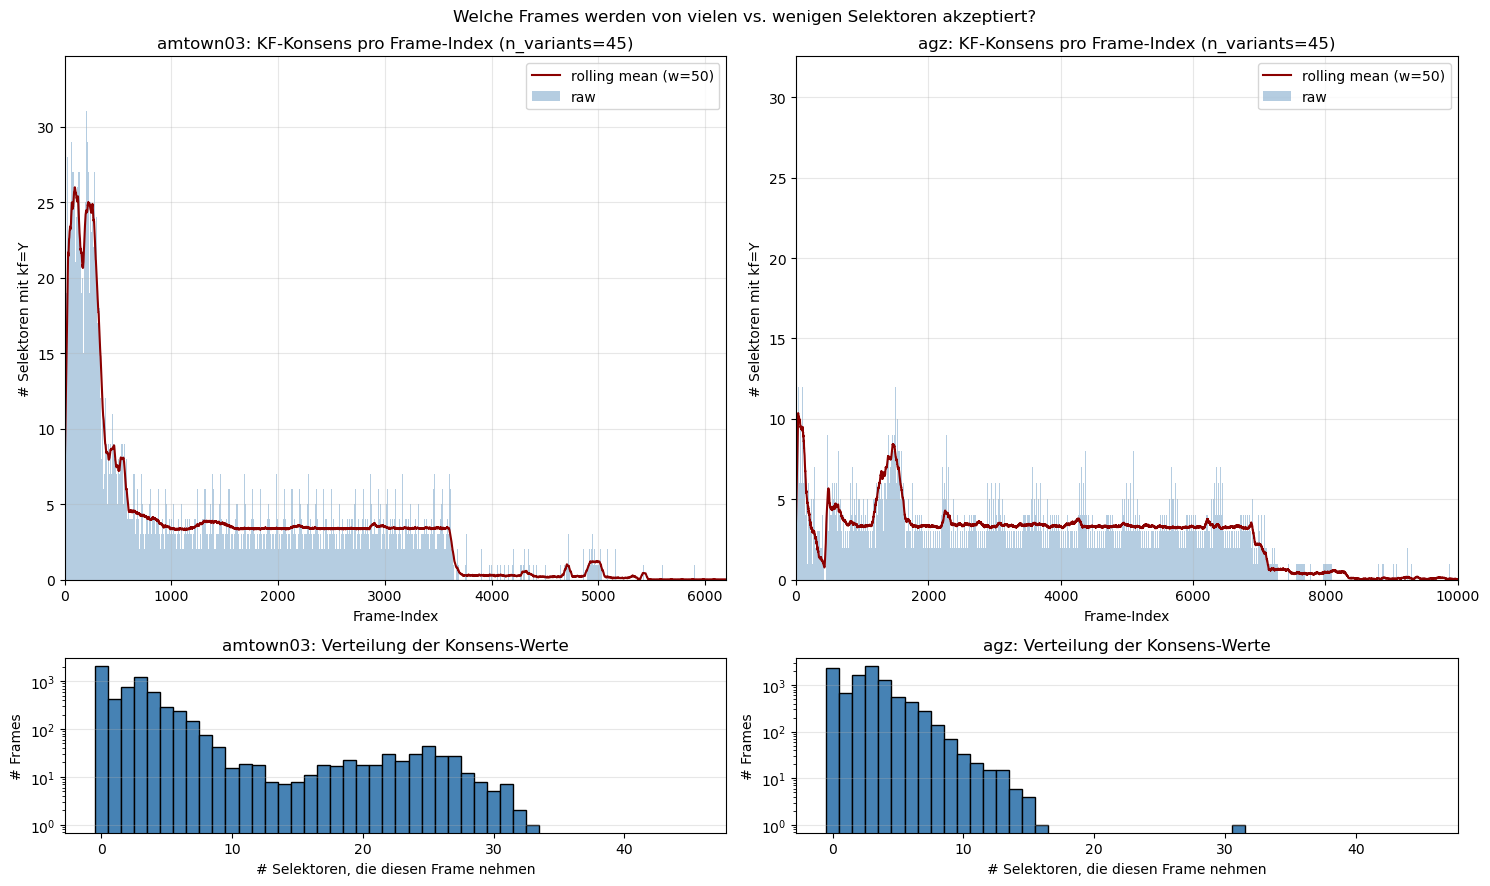

In [18]:
N_FRAMES = {'amtown03': 6199, 'agz': 10000}

fig, axes = plt.subplots(2, 2, figsize=(15, 9), gridspec_kw={'height_ratios':[3,1]})
for col, ds in enumerate(['amtown03','agz']):
    n = N_FRAMES[ds]
    consensus = np.zeros(n, dtype=np.int32)
    n_variants = 0
    for (d, v), frames in frames_by_variant.items():
        if d != ds: continue
        n_variants += 1
        valid = frames[frames < n]
        consensus[valid] += 1
    # Glättung für Trend
    window = max(50, n // 200)
    smoothed = np.convolve(consensus, np.ones(window)/window, mode='same')

    ax = axes[0, col]
    ax.bar(np.arange(n), consensus, width=1.0, color='steelblue', alpha=0.4, label='raw')
    ax.plot(smoothed, color='darkred', lw=1.5, label=f'rolling mean (w={window})')
    ax.set_title(f'{ds}: KF-Konsens pro Frame-Index (n_variants={n_variants})')
    ax.set_xlabel('Frame-Index'); ax.set_ylabel('# Selektoren mit kf=Y')
    ax.set_xlim(0, n); ax.grid(alpha=0.3); ax.legend()

    # Histogramm der Konsens-Werte: wie viele Frames erreichen wieviele Selektoren?
    ax2 = axes[1, col]
    bins = np.arange(0, n_variants+2) - 0.5
    ax2.hist(consensus, bins=bins, color='steelblue', edgecolor='black')
    ax2.set_title(f'{ds}: Verteilung der Konsens-Werte')
    ax2.set_xlabel('# Selektoren, die diesen Frame nehmen'); ax2.set_ylabel('# Frames')
    ax2.set_yscale('log'); ax2.grid(alpha=0.3, axis='y')

fig.suptitle('Welche Frames werden von vielen vs. wenigen Selektoren akzeptiert?', fontsize=12)
fig.tight_layout(); plt.show()

## 5) Top-N Runs nach PSNR

**Mit Coverage-Caveat:** `n_metric_frames` zeigt, wie viele Frames in die PSNR-Mittelung eingingen. Niedriger Wert = PSNR ist nur ein Anfangs-Snippet, nicht der ganze Run.

In [19]:
cols = ['dataset','group','variant','status3','psnr','ssim','lpips','n_metric_frames','n_mapped','wall_total_s','duration_min']
for ds in ['amtown03','agz']:
    print(f'\n=== Top-10 PSNR — {ds} ===')
    top = df[df['dataset']==ds].nlargest(10, 'psnr')[cols]
    print(top.to_string(index=False))

# Coverage-bereinigt: nur Runs mit ≥ 30% des Datasets als Metric-Frames
print('\n=== Top-5 PSNR (coverage ≥ 30 % der Tracker-KFs) ===')
df['coverage_ratio'] = df['n_metric_frames'] / df['n_keyframes'].clip(lower=1)
for ds in ['amtown03','agz']:
    sub = df[(df['dataset']==ds) & (df['coverage_ratio']>=0.30)].nlargest(5, 'psnr')[cols+['coverage_ratio']]
    print(f'\n--- {ds} ---'); print(sub.to_string(index=False))


=== Top-10 PSNR — amtown03 ===
 dataset          group            variant status3    psnr   ssim  lpips  n_metric_frames  n_mapped  wall_total_s  duration_min
amtown03 skip_no_filter    nofilter_skip_5 partial 23.5516 0.7202 0.3068             95.0       140         332.1          6.05
amtown03        mapskip          mapskip_1 partial 21.8090 0.7067 0.2651            263.0      3550         641.6         11.03
amtown03        mapskip          mapskip_2 partial 21.6394 0.6928 0.2796            272.0      1805         612.6         10.62
amtown03        mapskip          mapskip_3 partial 21.5186 0.6934 0.2774            264.0      1187         571.5          9.82
amtown03        mapskip          mapskip_5 partial 21.1362 0.6771 0.2977            280.0       730         541.2          9.32
amtown03    adaptive_kf  adaptive_kf_sens3 partial 20.9349 0.7273 0.3520            247.0       333        1493.8         25.32
amtown03 skip_no_filter    nofilter_skip_3 partial 20.6907 0.5979 0.3895

## 6) Wo fehlen Daten?

Heatmap: pro Run welche Metric-Spalten leer/NaN sind.

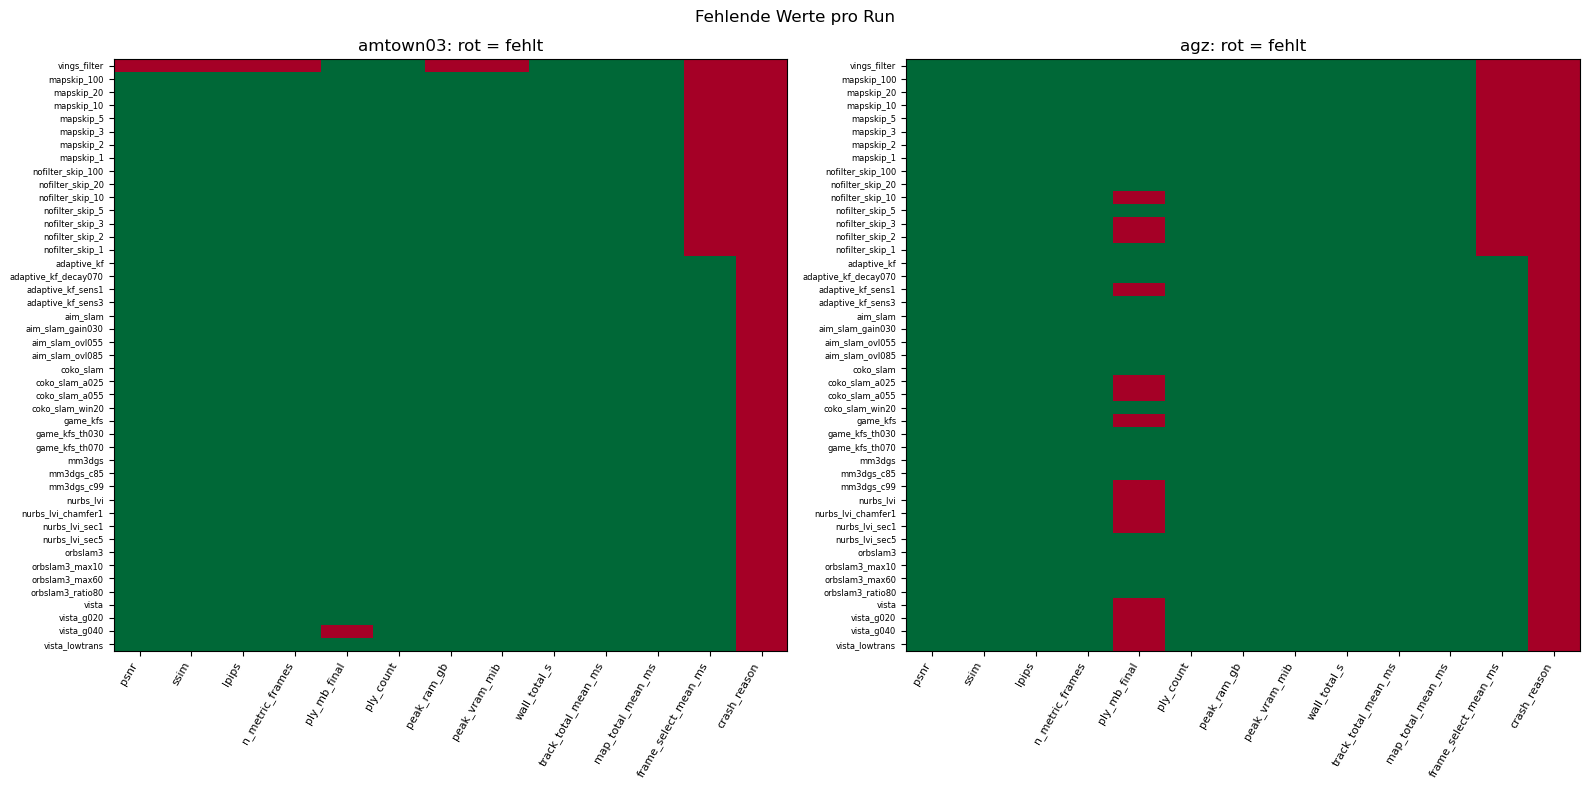

Spalten mit NaN-Anteil > 0 (über alle Runs):
crash_reason            100.0
frame_select_mean_ms     33.3
ply_mb_final             17.8
psnr                      1.1
ssim                      1.1
n_metric_frames           1.1
lpips                     1.1
peak_ram_gb               1.1
peak_vram_mib             1.1


In [20]:
metric_cols = ['psnr','ssim','lpips','n_metric_frames','ply_mb_final','ply_count','peak_ram_gb','peak_vram_mib',
               'wall_total_s','track_total_mean_ms','map_total_mean_ms','frame_select_mean_ms','crash_reason']
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, ds in zip(axes, ['amtown03','agz']):
    sub = df[df['dataset']==ds].copy().reset_index(drop=True)
    mat = sub[metric_cols].isna().values.astype(int)
    im = ax.imshow(mat, aspect='auto', cmap='RdYlGn_r', interpolation='nearest', vmin=0, vmax=1)
    ax.set_xticks(range(len(metric_cols))); ax.set_xticklabels(metric_cols, rotation=60, ha='right', fontsize=8)
    ax.set_yticks(range(len(sub))); ax.set_yticklabels(sub['variant'], fontsize=6)
    ax.set_title(f'{ds}: rot = fehlt')
fig.suptitle('Fehlende Werte pro Run', fontsize=12)
fig.tight_layout(); plt.show()

print('Spalten mit NaN-Anteil > 0 (über alle Runs):')
nan_share = df[metric_cols].isna().mean().sort_values(ascending=False)
print((nan_share[nan_share>0]*100).round(1).to_string())

## Quick-Take

Die wichtigsten Beobachtungen lese ich direkt aus den Plots oben ab:

- **FAIL ist meistens kein echter Crash**, sondern Watchdog-Kill (rc=137). Echte „dead"-Runs sind vor allem vista-Varianten auf agz und ein paar `_c99` / `nofilter_skip` mit zu wenig Frames.
- **Top-PSNR-Liste ohne Coverage-Filter ist Quark**: Sieger sind Sparse-Runs mit < 200 gemappten Frames. Coverage-bereinigte Top-5 zeigt das echte Ranking.
- **`mapskip_100` ist der einzige Run-Pfad, der reliabel überlebt** — sobald der Mapper mehr Arbeit bekommt, drückt der Watchdog.
- **vista crasht agz konsistent in einen Schrott-State** (PSNR ~11, <40 Metric-Frames).
- **Selector-Overhead ist irrelevant**: alle unter 21 ms, vs. Tracker 200-250 ms.
- **KF-Konsens-Histogramm zeigt**, ob es „universelle KFs" gibt (Bewegungs-Spitzen die alle Selektoren akzeptieren) oder ob die Algorithmen wirklich unterschiedlich entscheiden.